<div align="center">
  <h3><b>ESCUELA POLITÉCNICA NACIONAL</b></h3>
  <h3><b>FACULTAD DE INGENIERÍA EN SISTEMAS</b></h3>
  <h3><b>INGENIERÍA EN CIENCIAS DE LA COMPUTACIÓN</b></h3>
  <h3><b>RECUPERACIÓN DE LA INFORMACIÓN</b></h3>
</div>

---
**Nombre**   Mark Hernández        
**Fecha**    04/05/26  
**Docente**  Iván Carrera

# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [1]:
import re, os

path2 = "..\\Data\\Gutenberg_1000"
files = os.listdir(path2)
contenidos_libros = []
nombres_libros = []
indice_invertido = {}
for file in files:
    # Se iteran los archivos
    with open(path2 + "\\" + file, "r", encoding="utf-8") as f:
        contenido = f.read().lower()
        # Extrae solo palabras (letras y números)
        palabras = re.findall(r'\w+', contenido)
        contenidos_libros.append(contenido)
        nombres_libros.append(file)
        vocabulario = set(palabras)
        for palabra in vocabulario:
            if palabra in indice_invertido:
                indice_invertido[palabra].append(file)
            else:
                indice_invertido[palabra] = [file]
print('Número de palabras del índice invertido: ',len(indice_invertido))
print(f"✓ Libros cargados: {len(contenidos_libros)}")

Número de palabras del índice invertido:  1061431
✓ Libros cargados: 1000


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1 y 2. Configuramos el vectorizador con el mismo patrón de tokenización de la Parte 0
vectorizer = TfidfVectorizer(token_pattern=r'\w+')
tfidf_matrix = vectorizer.fit_transform(contenidos_libros)

# Obtenemos el vocabulario mapeado por sklearn
terminos = vectorizer.get_feature_names_out()

# 3. Visualizamos una muestra de términos en un DataFrame para analizar diferencias
# Tomamos una muestra representativa de palabras para no saturar la memoria
muestra_palabras = ['science', 'computer', 'book', 'the', 'island', 'secret']
df_valores = []

for term in muestra_palabras:
    if term in vectorizer.vocabulary_:
        idx = vectorizer.vocabulary_[term]
        # DF es el número de documentos que contienen el término (usamos el índice invertido creadio antes)
        df_t = len(indice_invertido.get(term, []))
        # IDF calculado por la variante de sklearn
        idf_t = vectorizer.idf_[idx]
        df_valores.append({'Término': term, 'DF (Doc Freq)': df_t, 'IDF (sklearn)': idf_t})

df_visualizacion = pd.DataFrame(df_valores)
print("✓ Matriz TF-IDF construida exitosamente.")
display(df_visualizacion)

✓ Matriz TF-IDF construida exitosamente.


,Término,DF (Doc Freq),IDF (sklearn)
0,science,499,1.694147
1,computer,387,1.947749
2,book,764,1.268879
3,the,1000,1.000000
4,island,471,1.751776
5,secret,691,1.369169


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [3]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Definimos una consulta de prueba
query = "secret treasure island adventure"
print(f"Consulta definida: '{query}'\n")

# 1. Construimos el vector de consulta en el mismo espacio que el corpus
query_vector = vectorizer.transform([query])

# 2. Calculamos la similitud coseno entre la consulta y cada documento del corpus
similitudes = cosine_similarity(tfidf_matrix, query_vector).flatten()

# 3 y 4. Generamos el ranking ordenado y lo estructuramos en un DataFrame
ranking_tfidf = pd.DataFrame({
    'Documento': nombres_libros,
    'Score TF-IDF': similitudes
})

ranking_tfidf = ranking_tfidf.sort_values(by='Score TF-IDF', ascending=False).reset_index(drop=True)
ranking_tfidf['Rank'] = ranking_tfidf.index + 1

print("Ranking Top 10 - Modelo Vectorial (TF-IDF):")
display(ranking_tfidf[['Rank', 'Documento', 'Score TF-IDF']].head(10))

Consulta definida: 'secret treasure island adventure'

Ranking Top 10 - Modelo Vectorial (TF-IDF):


,Rank,Documento,Score TF-IDF
0,1,book55479.txt,0.040497
1,2,book43670.txt,0.033595
2,3,book12878.txt,0.033149
3,4,book59070.txt,0.027281
4,5,book46032.txt,0.023618
5,6,book23256.txt,0.022733
6,7,book3054.txt,0.021496
7,8,book46.txt,0.020131
8,9,book120.txt,0.019805
9,10,book52462.txt,0.019734


## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [4]:
import math

# 1 y 2. Tokenización y cálculo de longitudes de documentos
tokens_por_libro = [re.findall(r'\w+', contenido) for contenido in contenidos_libros]
doc_lengths = [len(tokens) for tokens in tokens_por_libro]

N = len(contenidos_libros)
avgdl = sum(doc_lengths) / N

# 5. Definición de parámetros BM25 (Rangos típicos)
k1 = 1.5
b = 0.75

# 6 y 7. Función para calcular el score BM25 de la colección ante una query
def calcular_ranking_bm25(query_text, tokens_por_doc, nombres, idx_invertido, avg_len, total_docs, k1=1.5, b=0.75):
    query_words = re.findall(r'\w+', query_text.lower())
    scores = np.zeros(total_docs)
    
    for t in query_words:
        if t in idx_invertido:
            # 4. Calcular DF e IDF de BM25 con corrección de 0.5
            df_t = len(idx_invertido[t])
            idf_bm25 = math.log((total_docs - df_t + 0.5) / (df_t + 0.5))
            
            # Control de piso en 0 si el IDF se vuelve negativo por términos ultra frecuentes
            if idf_bm25 < 0:
                idf_bm25 = 0
            
            # Calculamos el aporte del término a cada documento
            for doc_idx, tokens in enumerate(tokens_por_doc):
                # 3. Calculamos TF (frecuencia de término en el documento)
                tf_t_d = tokens.count(t)
                
                if tf_t_d > 0:
                    L_d = len(tokens)
                    # 6. Ecuación estándar de Okapi BM25
                    numerador = (k1 + 1) * tf_t_d
                    denominador = k1 * ((1 - b) + b * (L_d / avg_len)) + tf_t_d
                    
                    scores[doc_idx] += idf_bm25 * (numerador / denominador)
                    
    # 8. Recuperamos y ordenamos el ranking
    df_res = pd.DataFrame({
        'Documento': nombres,
        'Score BM25': scores
    }).sort_values(by='Score BM25', ascending=False).reset_index(drop=True)
    df_res['Rank'] = df_res.index + 1
    return df_res

# Ejecutamos el ranking BM25 con la misma consulta
ranking_bm25 = calcular_ranking_bm25(query, tokens_por_libro, nombres_libros, indice_invertido, avgdl, N, k1, b)

print("Ranking Top 10 - Modelo Probabilístico (BM25):")
display(ranking_bm25[['Rank', 'Documento', 'Score BM25']].head(10))

Ranking Top 10 - Modelo Probabilístico (BM25):


,Rank,Documento,Score BM25
0,1,book43670.txt,1.905667
1,2,book120.txt,1.853849
2,3,book46.txt,1.852004
3,4,book13859.txt,1.824589
4,5,book56083.txt,1.813340
5,6,book40.txt,1.807829
6,7,book41708.txt,1.794712
7,8,book10008.txt,1.764886
8,9,book56457.txt,1.733073
9,10,book43212.txt,1.721265


## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

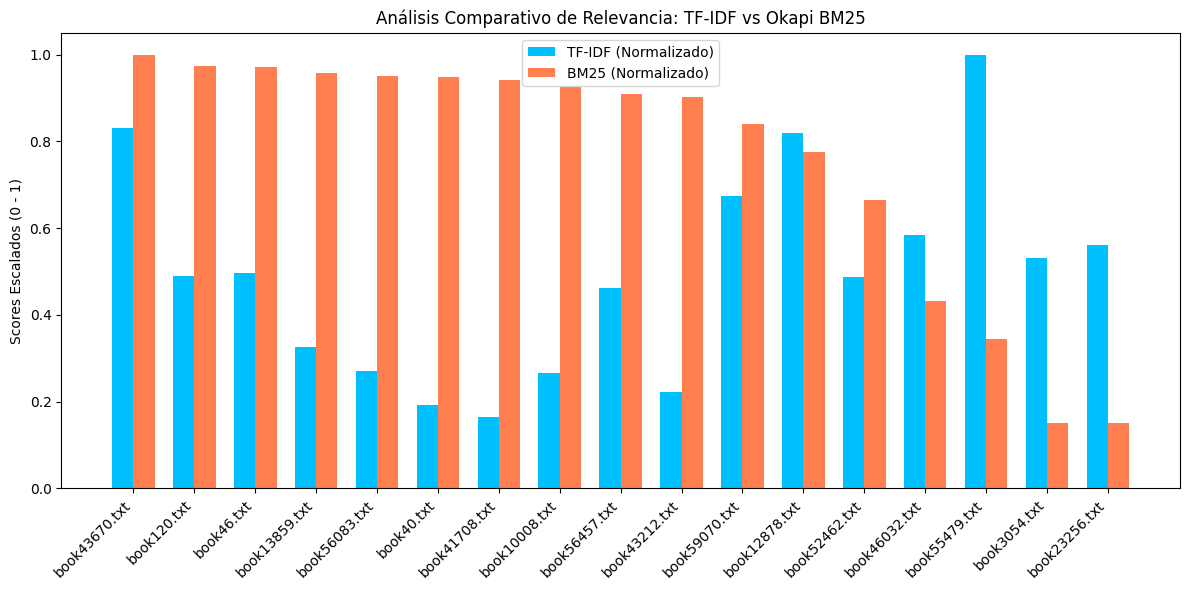

In [5]:
import matplotlib.pyplot as plt

# Combinamos los documentos del Top 10 de ambos modelos para una comparación justa
docs_top = list(set(ranking_tfidf['Documento'].head(10)).union(set(ranking_bm25['Documento'].head(10))))

df_comp = pd.DataFrame({'Documento': docs_top})
df_comp = df_comp.merge(ranking_tfidf[['Documento', 'Score TF-IDF']], on='Documento')
df_comp = df_comp.merge(ranking_bm25[['Documento', 'Score BM25']], on='Documento')

# Normalizamos las puntuaciones respecto al máximo valor de cada modelo
df_comp['TF-IDF Normalizado'] = df_comp['Score TF-IDF'] / df_comp['Score TF-IDF'].max()
df_comp['BM25 Normalizado'] = df_comp['Score BM25'] / df_comp['Score BM25'].max()
df_comp = df_comp.sort_values(by='BM25 Normalizado', ascending=False)

# Construimos el gráfico de barras comparativo
x = np.arange(len(df_comp))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, df_comp['TF-IDF Normalizado'], width, label='TF-IDF (Normalizado)', color='deepskyblue')
ax.bar(x + width/2, df_comp['BM25 Normalizado'], width, label='BM25 (Normalizado)', color='coral')

ax.set_ylabel('Scores Escalados (0 - 1)')
ax.set_title('Análisis Comparativo de Relevancia: TF-IDF vs Okapi BM25')
ax.set_xticks(x)
ax.set_xticklabels(df_comp['Documento'], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()